# LSTM Classifier for Cache Occupancy Memorygrams

This notebook builds an LSTM classifier to classify cache occupancy time series data from different stress-ng workloads.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

2026-03-17 15:54:02.160784: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 15:54:02.196053: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 15:54:03.145928: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Define data path
data_root = Path('/home/ubu/Desktop/Michael/lazyMapping_Prober/stable/64C_15TST_500SST')
# Get all class directories
classes = sorted([d for d in data_root.iterdir() if d.is_dir()])
class_names = [c.name for c in classes]
num_classes = len(class_names)

print(f"Found {num_classes} classes:")
for i, cls in enumerate(class_names):
    print(f"  {i}: {cls}")

Found 25 classes:
  0: bsearch
  1: cache
  2: heapsort
  3: hsearch
  4: icache
  5: judy
  6: lockbus
  7: lsearch
  8: malloc
  9: matrix
  10: matrix-3d
  11: membarrier
  12: memcpy
  13: mergesort
  14: qsort
  15: radixsort
  16: shellsort
  17: skiplist
  18: str
  19: stream
  20: tree
  21: tsearch
  22: vecmath
  23: wcs
  24: zlib


In [3]:
def load_memorygram(csv_path):
    """
    Load a single memorygram CSV file.
    
    Args:
        csv_path: Path to CSV file
    
    Returns:
        A 2D numpy array of shape (time_steps, clusters)
        where time_steps is the number of rows (excluding header)
        and clusters is the number of columns (64 for G0-G63)
    """
    df = pd.read_csv(csv_path)
    # Skip the first row (header) and return values as numpy array
    # Shape: (rows, 64 clusters)
    return df.values


def load_dataset(data_root, class_names):
    """
    Load all memorygrams for all classes.
    
    Args:
        data_root: Path to root data directory
        class_names: List of class directory names
    
    Returns:
        X: List of memorygrams (2D arrays)
        y: List of class labels (integers)
        class_indices: Dict mapping class name to integer label
    """
    X = []
    y = []
    class_indices = {cls: i for i, cls in enumerate(class_names)}
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = data_root / class_name
        csv_files = sorted(class_dir.glob('*.csv'))
        
        print(f"Loading {class_name}: {len(csv_files)} samples...", end=' ')
        
        for csv_file in csv_files:
            try:
                memorygram = load_memorygram(csv_file)
                X.append(memorygram)
                y.append(class_idx)
            except Exception as e:
                print(f"Error loading {csv_file}: {e}")
        
        print(f"✓")
    
    return X, y, class_indices


# Load all data
print("Loading dataset...")
X, y, class_indices = load_dataset(data_root, class_names)
print(f"\nTotal samples loaded: {len(X)}")
print(f"Sample shape (first memorygram): {X[0].shape}")

Loading dataset...
Loading bsearch: 50 samples... ✓
Loading cache: 50 samples... ✓
Loading heapsort: 50 samples... ✓
Loading hsearch: 50 samples... ✓
Loading icache: 50 samples... ✓
Loading judy: 50 samples... ✓
Loading lockbus: 50 samples... ✓
Loading lsearch: 50 samples... ✓
Loading malloc: 50 samples... ✓
Loading matrix: 50 samples... ✓
Loading matrix-3d: 50 samples... ✓
Loading membarrier: 50 samples... ✓
Loading memcpy: 50 samples... ✓
Loading mergesort: 50 samples... ✓
Loading qsort: 50 samples... ✓
Loading radixsort: 50 samples... ✓
Loading shellsort: 50 samples... ✓
Loading skiplist: 50 samples... ✓
Loading str: 50 samples... ✓
Loading stream: 50 samples... ✓
Loading tree: 50 samples... ✓
Loading tsearch: 50 samples... ✓
Loading vecmath: 50 samples... ✓
Loading wcs: 50 samples... ✓
Loading zlib: 50 samples... ✓

Total samples loaded: 1250
Sample shape (first memorygram): (468, 64)


In [4]:
def preprocess_data(X, y, max_length=None):
    """
    Preprocess the memorygrams:
    1. Normalize each memorygram independently
    2. Pad sequences to uniform length
    
    Args:
        X: List of memorygrams (2D arrays)
        y: List of labels
        max_length: Maximum sequence length. If None, use the longest sequence
    
    Returns:
        X_padded: Normalized and padded array of shape (samples, max_length, clusters)
        y_array: Label array
        max_len: The max_length used
    """
    # Find max length if not provided
    if max_length is None:
        max_len = max(mem.shape[0] for mem in X)
    else:
        max_len = max_length
    
    print(f"Using sequence length: {max_len} time steps")
    print(f"Number of features (clusters): 64")
    
    X_padded = np.zeros((len(X), max_len, X[0].shape[1]))
    
    for i, memorygram in enumerate(X):
        # Normalize each memorygram using StandardScaler
        scaler = StandardScaler()
        normalized = scaler.fit_transform(memorygram)
        
        # Pad or truncate to max_len
        if normalized.shape[0] < max_len:
            # Pad with zeros
            padded = np.zeros((max_len, normalized.shape[1]))
            padded[:normalized.shape[0], :] = normalized
        else:
            # Truncate to max_len
            padded = normalized[:max_len, :]
        
        X_padded[i] = padded
    
    y_array = np.array(y)
    
    return X_padded, y_array, max_len


# Preprocess the data
print("Preprocessing data...")
X_processed, y_processed, sequence_length = preprocess_data(X, y)
print(f"Processed data shape: {X_processed.shape}")
print(f"Labels shape: {y_processed.shape}")
print(f"\nClass distribution:")
for i, cls_name in enumerate(class_names):
    count = np.sum(y_processed == i)
    print(f"  {cls_name}: {count} samples")

Preprocessing data...
Using sequence length: 468 time steps
Number of features (clusters): 64
Processed data shape: (1250, 468, 64)
Labels shape: (1250,)

Class distribution:
  bsearch: 50 samples
  cache: 50 samples
  heapsort: 50 samples
  hsearch: 50 samples
  icache: 50 samples
  judy: 50 samples
  lockbus: 50 samples
  lsearch: 50 samples
  malloc: 50 samples
  matrix: 50 samples
  matrix-3d: 50 samples
  membarrier: 50 samples
  memcpy: 50 samples
  mergesort: 50 samples
  qsort: 50 samples
  radixsort: 50 samples
  shellsort: 50 samples
  skiplist: 50 samples
  str: 50 samples
  stream: 50 samples
  tree: 50 samples
  tsearch: 50 samples
  vecmath: 50 samples
  wcs: 50 samples
  zlib: 50 samples


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

# Convert labels to one-hot encoding for categorical classification
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Input shape (time_steps, clusters): ({sequence_length}, 64)")
print(f"Number of classes: {num_classes}")

Training set size: 1000
Testing set size: 250
Input shape (time_steps, clusters): (468, 64)
Number of classes: 25


In [6]:
# Build LSTM model
def build_lstm_model(sequence_length, num_features, num_classes):
    """
    Build an LSTM classifier model.
    
    Args:
        sequence_length: Number of time steps
        num_features: Number of features per time step (64 clusters)
        num_classes: Number of output classes
    
    Returns:
        Compiled Keras model
    """
    model = Sequential([
        # First LSTM layer with 128 units, returns sequences for stacking
        LSTM(128, activation='relu', return_sequences=True, 
             input_shape=(sequence_length, num_features)),
        Dropout(0.2),
        
        # Second LSTM layer with 64 units, returns sequences
        LSTM(64, activation='relu', return_sequences=True),
        Dropout(0.2),
        
        # Third LSTM layer with 32 units (processes full sequence)
        LSTM(32, activation='relu'),
        Dropout(0.2),
        
        # Dense layers for classification
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    return model


# Create and compile the model
model = build_lstm_model(sequence_length, 64, num_classes)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model summary:")
model.summary()

Model summary:


2026-03-17 15:54:06.818305: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 468, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 468, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 468, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 468, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │           825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,657 (647.10 KB)

 Trainable params: 165,657 (647.10 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the model
print("Training the model...")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train_categorical,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training the model...
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.0365 - loss: 3.2205 - val_accuracy: 0.0450 - val_loss: 160.5291
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0437 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0467 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0376 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0502 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0376 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.0424 - loss: nan - val_accuracy: 0.0400 - val_loss: nan
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.0364 - loss: nan - val_accuracy: 0.0400 - val_los

In [8]:
# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_categorical, axis=1)

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls_name in enumerate(class_names):
    mask = y_test_classes == i
    if mask.sum() > 0:
        class_accuracy = np.mean(y_pred_classes[mask] == y_test_classes[mask])
        print(f"  {cls_name}: {class_accuracy:.4f} ({mask.sum()} samples)")

Evaluating on test set...
Test Loss: 26.4968
Test Accuracy: 0.0440

Per-class accuracy:
  bsearch: 0.0000 (10 samples)
  cache: 0.0000 (10 samples)
  heapsort: 0.0000 (10 samples)
  hsearch: 0.0000 (10 samples)
  icache: 0.0000 (10 samples)
  judy: 0.0000 (10 samples)
  lockbus: 0.0000 (10 samples)
  lsearch: 0.0000 (10 samples)
  malloc: 0.0000 (10 samples)
  matrix: 0.0000 (10 samples)
  matrix-3d: 0.0000 (10 samples)
  membarrier: 0.0000 (10 samples)
  memcpy: 0.0000 (10 samples)
  mergesort: 0.0000 (10 samples)
  qsort: 0.0000 (10 samples)
  radixsort: 0.0000 (10 samples)
  shellsort: 0.0000 (10 samples)
  skiplist: 0.0000 (10 samples)
  str: 0.1000 (10 samples)
  stream: 1.0000 (10 samples)
  tree: 0.0000 (10 samples)
  tsearch: 0.0000 (10 samples)
  vecmath: 0.0000 (10 samples)
  wcs: 0.0000 (10 samples)
  zlib: 0.0000 (10 samples)


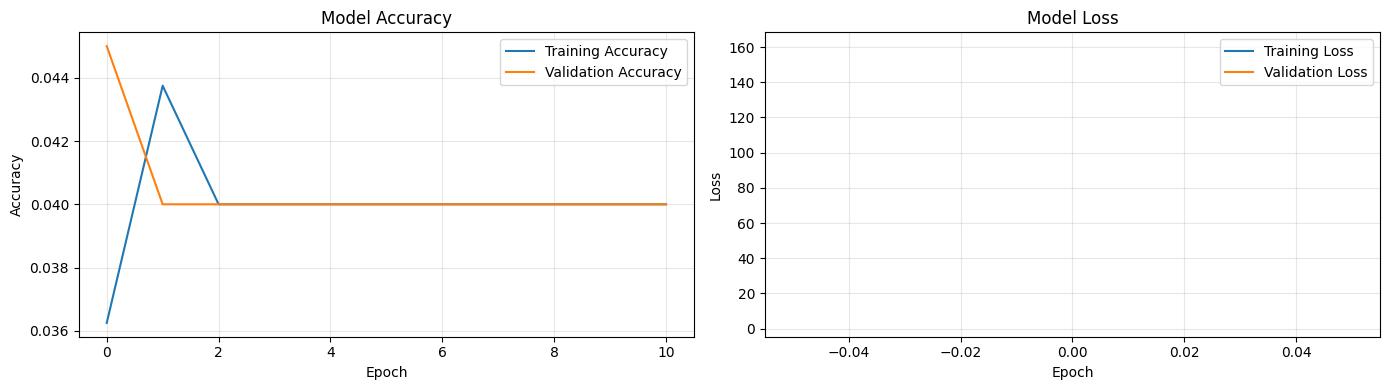

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

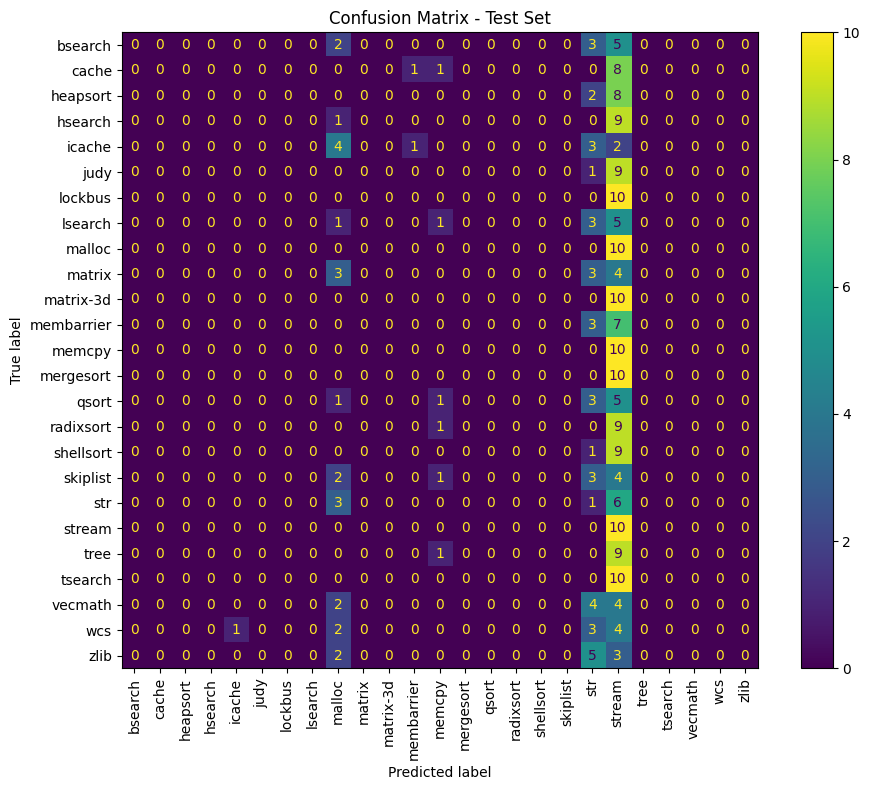

Confusion Matrix:
[[ 0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  3  5  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  0  0  0  8  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  8  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  9  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  4  0  0  1  0  0  0  0  0  0  3  2  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  9  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  1  0  0  0  0  0  3  5  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  3  4  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  7  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [11]:
def predict_memorygram(model, csv_path, class_names, sequence_length):
    """
    Make a prediction on a single memorygram CSV file.
    
    Args:
        model: Trained LSTM model
        csv_path: Path to the memorygram CSV file
        class_names: List of class names
        sequence_length: Expected sequence length
    
    Returns:
        Predicted class name and confidence scores
    """
    # Load and preprocess the memorygram
    memorygram = load_memorygram(csv_path)
    
    # Normalize
    scaler = StandardScaler()
    normalized = scaler.fit_transform(memorygram)
    
    # Pad or truncate
    if normalized.shape[0] < sequence_length:
        padded = np.zeros((sequence_length, normalized.shape[1]))
        padded[:normalized.shape[0], :] = normalized
    else:
        padded = normalized[:sequence_length, :]
    
    # Make prediction
    prediction = model.predict(np.array([padded]), verbose=0)[0]
    predicted_class_idx = np.argmax(prediction)
    predicted_class_name = class_names[predicted_class_idx]
    confidence = prediction[predicted_class_idx]
    
    return predicted_class_name, confidence, prediction


# Example: predict on a test sample
print("Example prediction on a test sample:")
test_sample_path = list((data_root / class_names[0]).glob('*.csv'))[0]
predicted_class, confidence, scores = predict_memorygram(model, test_sample_path, class_names, sequence_length)
print(f"Sample: {test_sample_path.name}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"\nClass probabilities:")
for cls, score in zip(class_names, scores):
    print(f"  {cls}: {score:.4f}")

Example prediction on a test sample:
Sample: 42.csv
Predicted class: stream
Confidence: 0.0445

Class probabilities:
  bsearch: 0.0385
  cache: 0.0408
  heapsort: 0.0369
  hsearch: 0.0403
  icache: 0.0409
  judy: 0.0404
  lockbus: 0.0427
  lsearch: 0.0389
  malloc: 0.0436
  matrix: 0.0372
  matrix-3d: 0.0366
  membarrier: 0.0414
  memcpy: 0.0433
  mergesort: 0.0374
  qsort: 0.0401
  radixsort: 0.0416
  shellsort: 0.0376
  skiplist: 0.0379
  str: 0.0430
  stream: 0.0445
  tree: 0.0368
  tsearch: 0.0402
  vecmath: 0.0396
  wcs: 0.0410
  zlib: 0.0387


# Random Forest Classifier (Flattened Features)

Training a Random Forest classifier with flattened memorygram features for comparison with the LSTM model.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

def flatten_memorygrams(X, y):
    """
    Flatten 2D memorygrams into 1D feature vectors.
    
    Args:
        X: List of memorygrams (2D arrays of shape (time_steps, clusters))
        y: List of labels
    
    Returns:
        X_flat: 2D numpy array of shape (samples, time_steps * clusters)
        y_array: 1D numpy array of labels
    """
    X_flat_list = []
    
    for memorygram in X:
        # Normalize the memorygram first
        scaler = StandardScaler()
        normalized = scaler.fit_transform(memorygram)
        
        # Flatten to 1D
        flattened = normalized.flatten()
        X_flat_list.append(flattened)
    
    X_flat = np.array(X_flat_list)
    y_array = np.array(y)
    
    return X_flat, y_array


# Flatten the original data (not the padded version)
print("Flattening memorygrams...")
X_flat, y_flat = flatten_memorygrams(X, y)
print(f"Flattened data shape: {X_flat.shape}")
print(f"Number of features: {X_flat.shape[1]}")
print(f"Number of samples: {X_flat.shape[0]}")

Flattening memorygrams...
Flattened data shape: (1250, 29952)
Number of features: 29952
Number of samples: 1250


In [13]:
# Split the flattened data
X_train_flat, X_test_flat, y_train_flat, y_test_flat = train_test_split(
    X_flat, y_flat, test_size=0.2, random_state=42, stratify=y_flat
)

print(f"Training set size: {X_train_flat.shape[0]}")
print(f"Testing set size: {X_test_flat.shape[0]}")
print(f"Features per sample: {X_train_flat.shape[1]}")

Training set size: 1000
Testing set size: 250
Features per sample: 29952


In [14]:
# Train Random Forest classifier
print("Training Random Forest classifier...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_flat, y_train_flat)
print("Training completed!")

Training Random Forest classifier...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    3.4s


Training completed!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    3.6s finished


In [15]:
# Evaluate Random Forest on test set
print("Evaluating Random Forest on test set...")

y_pred_rf = rf_model.predict(X_test_flat)
rf_accuracy = accuracy_score(y_test_flat, y_pred_rf)

print(f"\nRandom Forest Test Accuracy: {rf_accuracy:.4f}")

# Per-class accuracy
print("\nPer-class accuracy (Random Forest):")
for i, cls_name in enumerate(class_names):
    mask = y_test_flat == i
    if mask.sum() > 0:
        class_accuracy = np.mean(y_pred_rf[mask] == y_test_flat[mask])
        print(f"  {cls_name}: {class_accuracy:.4f} ({mask.sum()} samples)")

Evaluating Random Forest on test set...

Random Forest Test Accuracy: 0.5080

Per-class accuracy (Random Forest):
  bsearch: 0.5000 (10 samples)
  cache: 0.2000 (10 samples)
  heapsort: 0.9000 (10 samples)
  hsearch: 0.4000 (10 samples)
  icache: 0.5000 (10 samples)
  judy: 0.6000 (10 samples)
  lockbus: 0.6000 (10 samples)
  lsearch: 0.4000 (10 samples)
  malloc: 0.5000 (10 samples)
  matrix: 0.2000 (10 samples)
  matrix-3d: 0.7000 (10 samples)
  membarrier: 0.8000 (10 samples)
  memcpy: 0.3000 (10 samples)
  mergesort: 0.2000 (10 samples)
  qsort: 0.7000 (10 samples)
  radixsort: 0.2000 (10 samples)
  shellsort: 1.0000 (10 samples)
  skiplist: 0.7000 (10 samples)
  str: 0.6000 (10 samples)
  stream: 1.0000 (10 samples)
  tree: 0.3000 (10 samples)
  tsearch: 0.2000 (10 samples)
  vecmath: 0.4000 (10 samples)
  wcs: 0.3000 (10 samples)
  zlib: 0.5000 (10 samples)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished


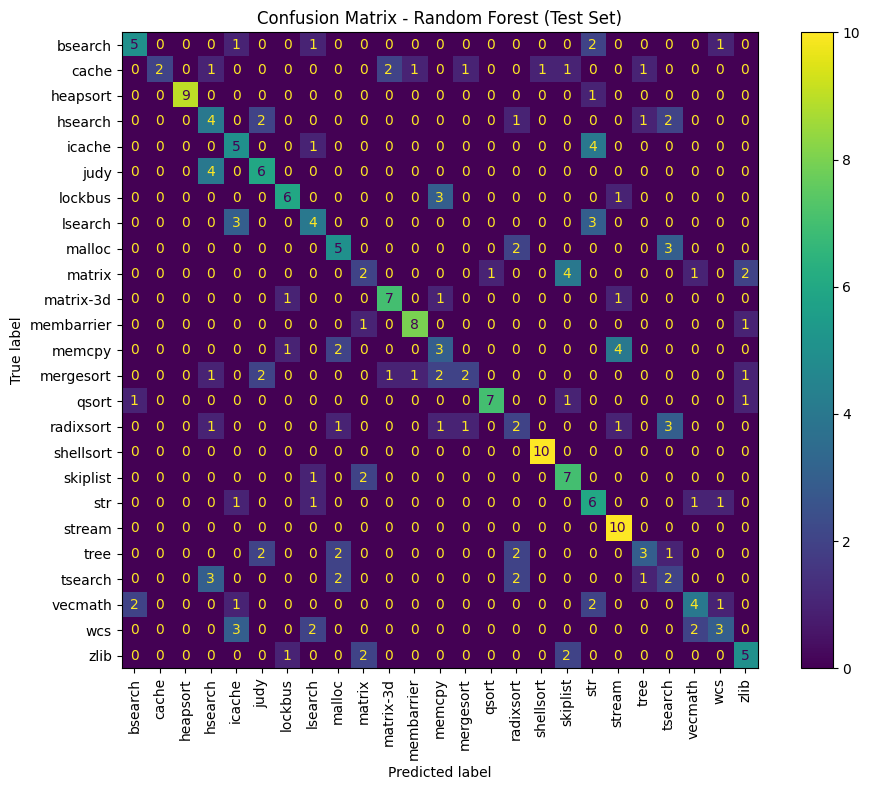

Random Forest Confusion Matrix:
[[ 5  0  0  0  1  0  0  1  0  0  0  0  0  0  0  0  0  0  2  0  0  0  0  1
   0]
 [ 0  2  0  1  0  0  0  0  0  0  2  1  0  1  0  0  1  1  0  0  1  0  0  0
   0]
 [ 0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0
   0]
 [ 0  0  0  4  0  2  0  0  0  0  0  0  0  0  0  1  0  0  0  0  1  2  0  0
   0]
 [ 0  0  0  0  5  0  0  1  0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0
   0]
 [ 0  0  0  4  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  6  0  0  0  0  0  3  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  3  0  0  4  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  2  0  0  0  0  0  3  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  2  0  0  0  0  1  0  0  4  0  0  0  0  1  0
   2]
 [ 0  0  0  0  0  0  1  0  0  0  7  0  1  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  1  0  8  0  0  0  0  0  0  0  0  0  0  0  0
   1]
 [ 0  0 

In [16]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_flat, y_pred_rf)

fig, ax = plt.subplots(figsize=(10, 8))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names)
disp_rf.plot(ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.tight_layout()
plt.show()

print("Random Forest Confusion Matrix:")
print(cm_rf)

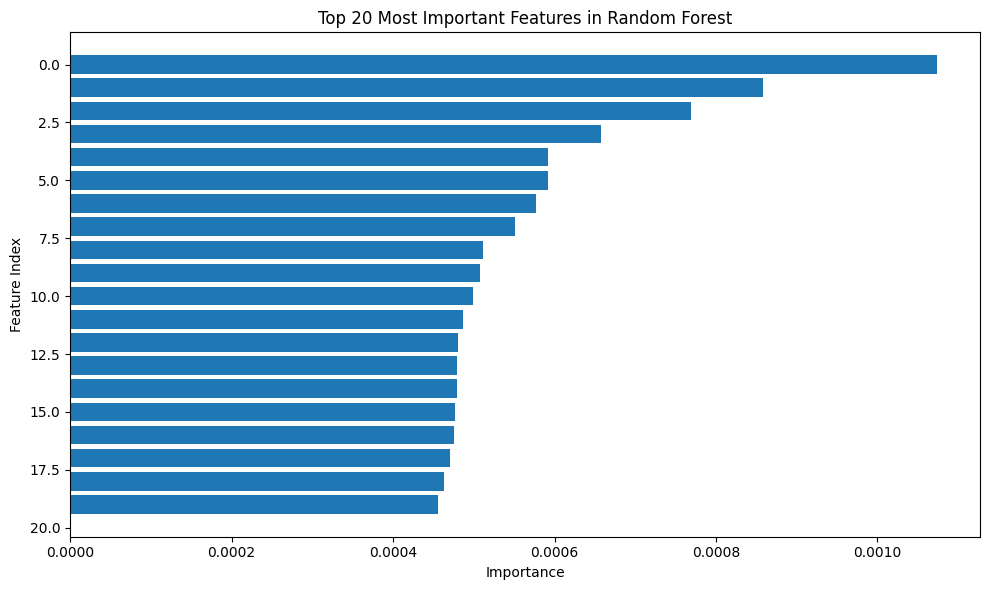

Top 20 feature indices and their importance:
  Feature 24: 0.001073
  Feature 0: 0.000858
  Feature 4: 0.000769
  Feature 79: 0.000658
  Feature 911: 0.000592
  Feature 83: 0.000592
  Feature 399: 0.000577
  Feature 445: 0.000551
  Feature 20: 0.000511
  Feature 469: 0.000507
  Feature 447: 0.000499
  Feature 391: 0.000487
  Feature 323: 0.000480
  Feature 521: 0.000479
  Feature 443: 0.000479
  Feature 199: 0.000477
  Feature 459: 0.000475
  Feature 457: 0.000470
  Feature 451: 0.000463
  Feature 455: 0.000456


In [17]:
# Feature importance analysis
feature_importance = rf_model.feature_importances_
top_k = 20

top_indices = np.argsort(feature_importance)[-top_k:][::-1]
top_importance = feature_importance[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_importance)), top_importance)
plt.xlabel('Importance')
plt.ylabel('Feature Index')
plt.title(f'Top {top_k} Most Important Features in Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top {top_k} feature indices and their importance:")
for idx, feat_idx in enumerate(top_indices):
    print(f"  Feature {feat_idx}: {feature_importance[feat_idx]:.6f}")

In [18]:
# Model comparison
print("=" * 60)
print("MODEL COMPARISON: LSTM vs Random Forest")
print("=" * 60)

print(f"\nLSTM Test Accuracy:          {test_accuracy:.4f}")
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

difference = rf_accuracy - test_accuracy
if difference > 0:
    print(f"\n✓ Random Forest is better by {difference:.4f}")
else:
    print(f"\n✓ LSTM is better by {abs(difference):.4f}")

# Create a comparison table
comparison_data = {
    'Model': ['LSTM', 'Random Forest'],
    'Test Accuracy': [test_accuracy, rf_accuracy],
    'Training Method': ['Deep Learning', 'Ensemble'],
    'Feature Type': ['Sequential (3D)', 'Flattened (2D)']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + str(comparison_df.to_string(index=False)))

MODEL COMPARISON: LSTM vs Random Forest

LSTM Test Accuracy:          0.0440
Random Forest Test Accuracy: 0.5080

✓ Random Forest is better by 0.4640

        Model  Test Accuracy Training Method    Feature Type
         LSTM          0.044   Deep Learning Sequential (3D)
Random Forest          0.508        Ensemble  Flattened (2D)


In [19]:
def predict_memorygram_rf(model, csv_path, class_names):
    """
    Make a prediction on a single memorygram CSV file using Random Forest.
    
    Args:
        model: Trained Random Forest model
        csv_path: Path to the memorygram CSV file
        class_names: List of class names
    
    Returns:
        Predicted class name and confidence scores
    """
    # Load and preprocess the memorygram
    memorygram = load_memorygram(csv_path)
    
    # Normalize
    scaler = StandardScaler()
    normalized = scaler.fit_transform(memorygram)
    
    # Flatten
    flattened = normalized.flatten().reshape(1, -1)
    
    # Make prediction
    prediction = model.predict(flattened)[0]
    prediction_proba = model.predict_proba(flattened)[0]
    predicted_class_name = class_names[prediction]
    confidence = prediction_proba[prediction]
    
    return predicted_class_name, confidence, prediction_proba


# Example: predict on a test sample using Random Forest
print("Example prediction using Random Forest:")
test_sample_path = list((data_root / class_names[0]).glob('*.csv'))[0]
predicted_class_rf, confidence_rf, scores_rf = predict_memorygram_rf(rf_model, test_sample_path, class_names)
print(f"Sample: {test_sample_path.name}")
print(f"Predicted class: {predicted_class_rf}")
print(f"Confidence: {confidence_rf:.4f}")
print(f"\nClass probabilities:")
for cls, score in zip(class_names, scores_rf):
    print(f"  {cls}: {score:.4f}")

Example prediction using Random Forest:
Sample: 42.csv
Predicted class: bsearch
Confidence: 0.5096

Class probabilities:
  bsearch: 0.5096
  cache: 0.0092
  heapsort: 0.0534
  hsearch: 0.0087
  icache: 0.0500
  judy: 0.0071
  lockbus: 0.0152
  lsearch: 0.0699
  malloc: 0.0067
  matrix: 0.0350
  matrix-3d: 0.0085
  membarrier: 0.0105
  memcpy: 0.0046
  mergesort: 0.0096
  qsort: 0.0276
  radixsort: 0.0000
  shellsort: 0.0031
  skiplist: 0.0279
  str: 0.0204
  stream: 0.0035
  tree: 0.0060
  tsearch: 0.0013
  vecmath: 0.0354
  wcs: 0.0522
  zlib: 0.0248


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
